In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


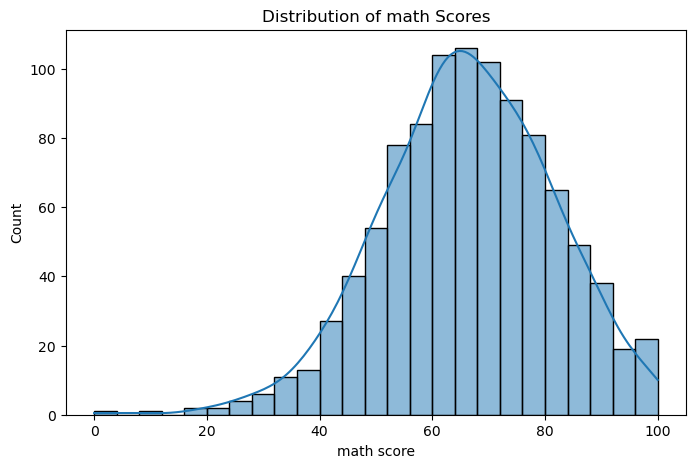

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'],kde=True)
plt.title("Distribution of math Scores")
plt.show()

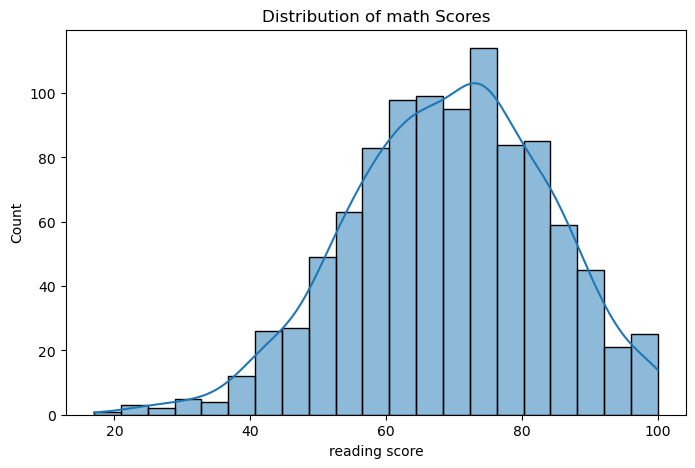

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['reading score'],kde=True)
plt.title("Distribution of math Scores")
plt.show()

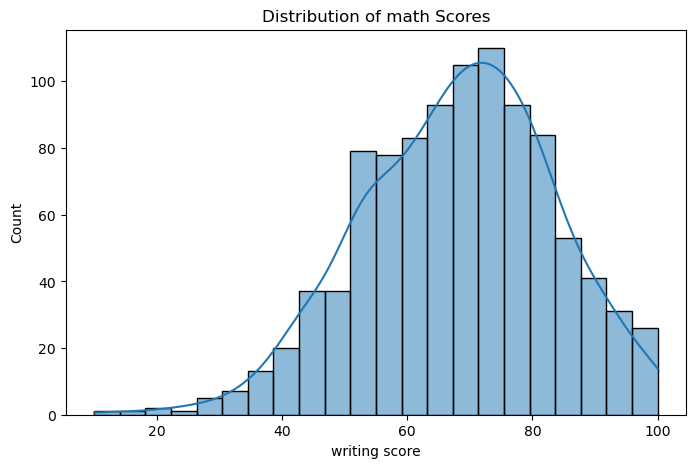

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['writing score'],kde=True)
plt.title("Distribution of math Scores")
plt.show()

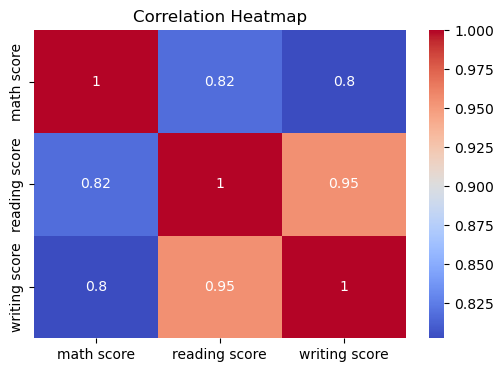

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score',
                'reading score',
                'writing score']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

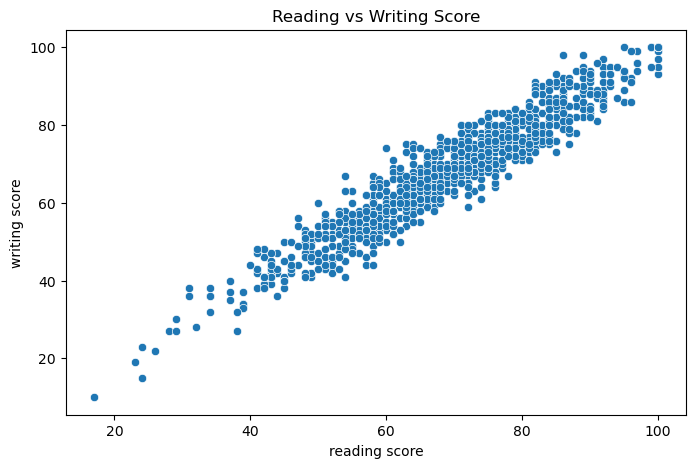

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='reading score',
                y='writing score',
                data=df)
plt.title("Reading vs Writing Score")
plt.show()

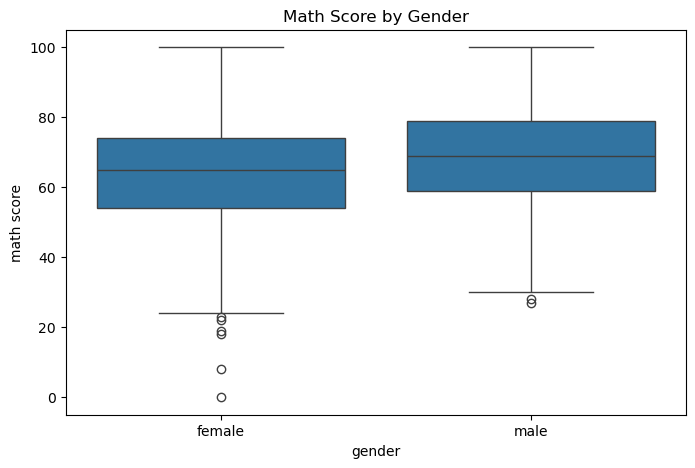

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender',
            y='math score',
            data=df)
plt.title("Math Score by Gender")
plt.show()

In [16]:
df[['math score',
    'reading score',
    'writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

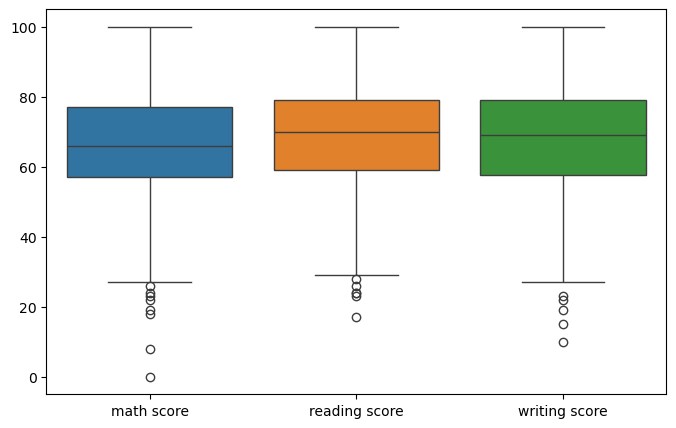

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['math score',
                     'reading score',
                     'writing score']])
plt.show()

In [18]:
X = df[['reading score', 'writing score']]
y = df['math score']

print(X.head())
print(y.head())

   reading score  writing score
0             72             74
1             90             88
2             95             93
3             57             44
4             78             75
0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 2)
X_test: (200, 2)
y_train: (800,)
y_test: (200,)


In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 7.85940588782988
Coefficients: [0.57555997 0.27176146]


In [24]:
y_pred = model.predict(X_test)

In [25]:
print(y_pred[:10])

[80.18552589 65.6849504  69.44210877 72.01611012 76.82827724 72.22379745
 65.26957575 59.81777453 69.44210877 50.08186415]


In [26]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
521,91,80.185526
737,53,65.684950
740,80,69.442109
660,74,72.016110
411,84,76.828277
678,81,72.223797
626,69,65.269576
513,54,59.817775
859,87,69.442109
136,51,50.081864


In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 7.351308782530512


In [29]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 77.24297821278957


In [30]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 8.788798451027851


In [31]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.6825697127424625


In [32]:
print("Model Evaluation")
print("----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
----------------
MAE : 7.351308782530512
MSE : 77.24297821278957
RMSE: 8.788798451027851
R² Score: 0.6825697127424625


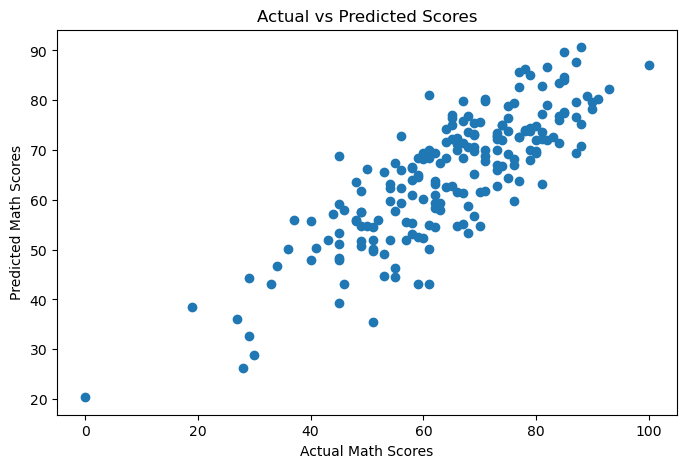

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Scores")
plt.ylabel("Predicted Math Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

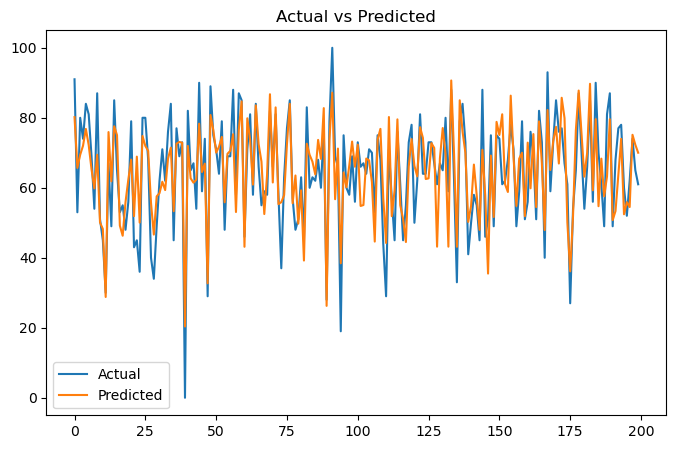

In [34]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [35]:
new_student = [[80, 85]]

predicted_score = model.predict(new_student)

print("Predicted Math Score:", predicted_score[0])

Predicted Math Score: 77.00392750342672


C:\Users\komal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
